Dataset shape: (1225252, 16)

Columns: ['VAERS_ID', 'AGE_YRS', 'SEX', 'STATE', 'YEAR', 'VAX_TYPE', 'VAX_MANU', 'VAX_DOSE_SERIES', 'DIED', 'L_THREAT', 'DISABLE', 'RECOVD', 'symptoms_list', 'age_bucket', 'any_serious', 'symptoms_normalized']

Outcome counts:
              DIED   L_THREAT    DISABLE  RECOVD  any_serious
No             NaN        NaN        NaN  368544          NaN
Unknown  1204786.0  1208176.0  1202477.0  491479    1169908.0
Yes        20466.0    17076.0    22775.0  365229      55344.0


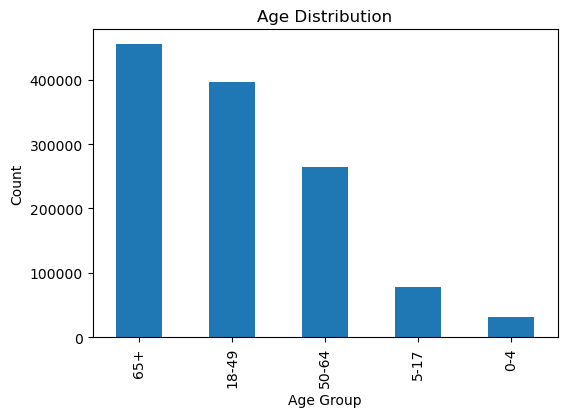

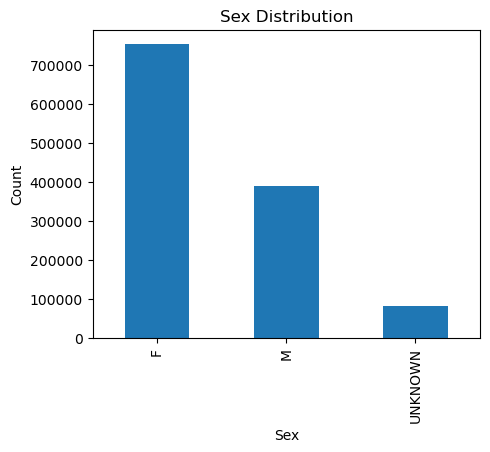

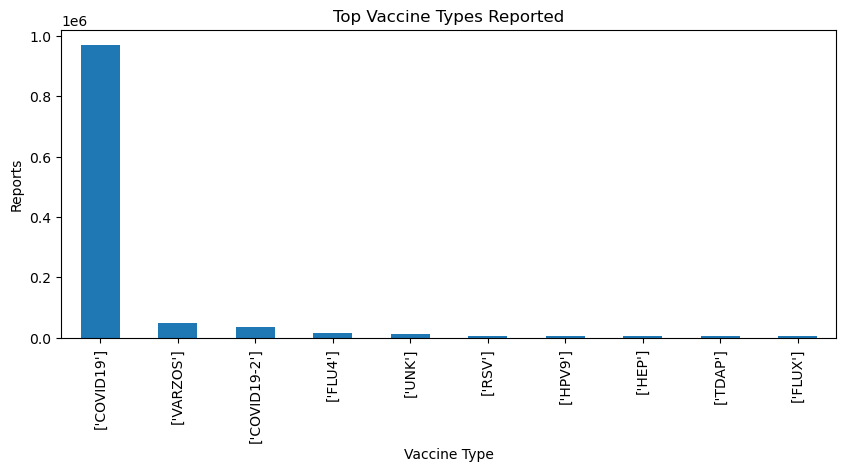

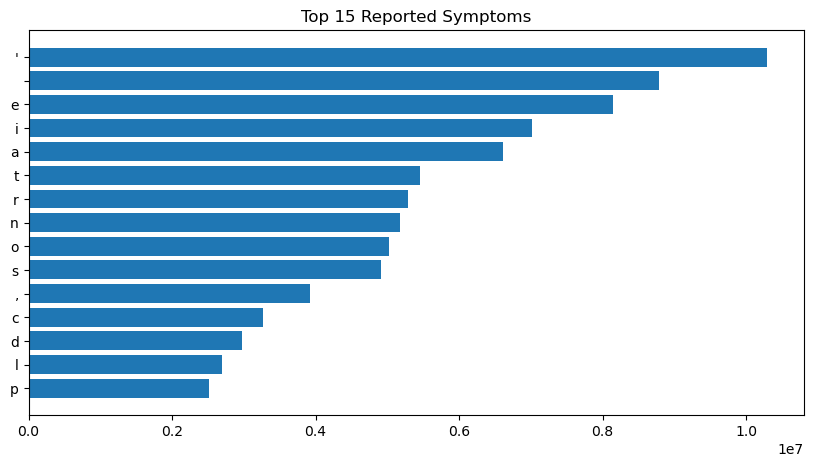

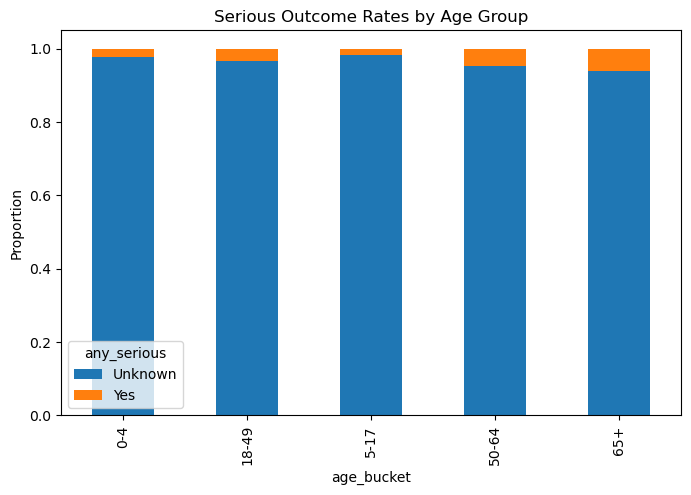

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv("vaers_sample_cleaned.csv")

#  EDA Section

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Outcome counts 
print("\nOutcome counts:")
print(df[["DIED", "L_THREAT", "DISABLE", "RECOVD", "any_serious"]].apply(pd.Series.value_counts))

# Age distribution
plt.figure(figsize=(6,4))
df["age_bucket"].value_counts().plot(kind="bar")
plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

# Sex distribution
plt.figure(figsize=(5,4))
df["SEX"].value_counts().plot(kind="bar")
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# Top vaccine types
plt.figure(figsize=(10,4))
df["VAX_TYPE"].value_counts().head(10).plot(kind="bar")
plt.title("Top Vaccine Types Reported")
plt.xlabel("Vaccine Type")
plt.ylabel("Reports")
plt.show()

# Top symptoms 
all_symptoms = [s for sublist in df["symptoms_list"] for s in sublist]
symptom_counts = Counter(all_symptoms)
top_symptoms = pd.DataFrame(symptom_counts.most_common(15), columns=["Symptom", "Count"])

plt.figure(figsize=(10,5))
plt.barh(top_symptoms["Symptom"], top_symptoms["Count"])
plt.title("Top 15 Reported Symptoms")
plt.gca().invert_yaxis()
plt.show()

# Serious outcomes by age group 
serious_by_age = df.groupby("age_bucket")["any_serious"].value_counts(normalize=True).unstack().fillna(0)
serious_by_age.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Serious Outcome Rates by Age Group")
plt.ylabel("Proportion")
plt.show()
